# Lab 3: Pandas

(Last update: 01/12/2024)

Full name: Lý Liên Hoa
Student ID: 22127117

---

**Summary**: In this assignment, you are going to learn how to use `Pandas`. Loops, and methods such as `apply/applymap` are not allowed to use unless specifically instructed to do so.

## 0. General instructions

### 0.0. Work on assignment

- You will do your assignment directly on this notebook file. First, you fill your name and student code at the beginning of the file. In this file, you will write your code when you see the following lines of code:
    ```python
    # TODO
    raise NotImplementedError()
    ```

    For optional coding parts, there will be:

    ```python
    # TODO (OPTIONAL)
    ```

    For markdown cell, there will be:

    ```markdown
    **TODO**: ...
    ```

- Of course, you have to remove the `raise NotImplementedError()` statement when you finish.

- For coding parts, there are often cells below to help you check your answers. You will pass the test if there are no errors when you run the test cells. In some cases, the tests are insufficient. That means if you do not pass the test, your answer is definitely wrong somewhere, but if you pass the test, your answer may still be incorrect.

- While doing the assignment, you should print out the output and create more cells for testing. But you have to remove all of them (comment your print-out codes, delete the cell created by you) when you submit your code. <font color=red>Do not remove or edit my cells</font> (except for the aforementioned cells).

- Keep your code clean and clear by using meaningful variable names and comments, not write too-long coding lines. Press `Ctrl + S` right after editing.

- **Keep it real**: The reason why you are here is to <font color=green>study, really study</font>. I highly recommend that you discuss your idea with your friends and <font color=green>write your own code based on your own knowledge</font>. <font color=red>Copy means zero.</font>

### 0.1. Submit your assignment

- When grading your assignment, I will choose `Kernel` - `Restart & Run All` in order to restart the kernel and run all cells in your notebook. Therefore, you should do that before submitting to ensure that the outputs are all as expected.

- After that, rename the notebook as `<StudentID>.ipynb`. For example, if your student code is 1234567, then your notebook is `1234567.ipynb`.

- Finally, submit your notebook file on Moodle. <font color=red>Please strictly follow the submission rules.</font>

---

## 1. Import libraries

In [1]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import warnings
warnings.simplefilter('ignore')

# TODO (OPTION): import your libraries
from matplotlib.ticker import FuncFormatter
import seaborn as sns

## 2. Data collection

- In this assignment, you are going to analyze **Most Streamed Spotify Songs 2024**. You are provided the following files:
    - `./Most Streamed Spotify Songs 2024.csv`.

- Data source: [Most Streamed Spotify Songs 2024 - Kaggle](https://www.kaggle.com/datasets/nelgiriyewithana/most-streamed-spotify-songs-2024).

## 3. Data pre-processing and exploration

- In this section, you are going to explore features of data. First, you have to read the data from `./Most Streamed Spotify Songs 2024.csv` and store it into a dataframe called `df`.

In [2]:
# TODO: read data from ./Most Streamed Spotify Songs 2024.csv and save to df then display 5 first lines of data
df = pd.read_csv('./Most Streamed Spotify Songs 2024.csv', encoding='unicode_escape')
df.head()

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1


### 3.0. How many rows/columns are there in the dataset?

- Save the number of rows and columns to `n_rows, n_cols`

In [3]:
# TODO: save your answer to n_rows, n_cols
n_rows, n_cols = df.shape
n_rows, n_cols

(4600, 29)

In [4]:
# TEST
assert (n_rows, n_cols) == (4600, 29)

### 3.1. Explore rows

- Is there any duplicate row? You will check it using `Pandas`.

In [5]:
# TODO: save your answer to is_duplicate
is_duplicate = df.duplicated().sum() > 0
is_duplicate

np.True_

In [6]:
# TEST
assert is_duplicate == True

So there are duplicate rows. Delete them and keep only one using Pandas.

In [7]:
# TODO: Remove duplicate rows and keep only one
df.drop_duplicates(keep='first', inplace=True)
df.shape

(4598, 29)

In [8]:
# TEST
assert df.shape == (4598, 29)

### 3.2. Explore columns

- Observe the data provided, carefully read the column titles as well as the data contained in the columns.
- Display the column names.

In [9]:
# TODO: Display the column nmes
df.columns

Index(['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC',
       'All Time Rank', 'Track Score', 'Spotify Streams',
       'Spotify Playlist Count', 'Spotify Playlist Reach',
       'Spotify Popularity', 'YouTube Views', 'YouTube Likes', 'TikTok Posts',
       'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach',
       'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins',
       'Deezer Playlist Count', 'Deezer Playlist Reach',
       'Amazon Playlist Count', 'Pandora Streams', 'Pandora Track Stations',
       'Soundcloud Streams', 'Shazam Counts', 'TIDAL Popularity',
       'Explicit Track'],
      dtype='object')

### 3.3. Handle missing data & Convert data

- Next, we start handling missing data. First thing first, please display the data information.

In [10]:
# TODO: Display data information
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4598 entries, 0 to 4599
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Track                       4598 non-null   object 
 1   Album Name                  4598 non-null   object 
 2   Artist                      4593 non-null   object 
 3   Release Date                4598 non-null   object 
 4   ISRC                        4598 non-null   object 
 5   All Time Rank               4598 non-null   object 
 6   Track Score                 4598 non-null   float64
 7   Spotify Streams             4485 non-null   object 
 8   Spotify Playlist Count      4528 non-null   object 
 9   Spotify Playlist Reach      4526 non-null   object 
 10  Spotify Popularity          3794 non-null   float64
 11  YouTube Views               4290 non-null   object 
 12  YouTube Likes               4283 non-null   object 
 13  TikTok Posts                3425 non-n

- Display number of NA values in each column.

In [11]:
# TODO: Display number of NA values in each column.
df.isna().sum()

Track                            0
Album Name                       0
Artist                           5
Release Date                     0
ISRC                             0
All Time Rank                    0
Track Score                      0
Spotify Streams                113
Spotify Playlist Count          70
Spotify Playlist Reach          72
Spotify Popularity             804
YouTube Views                  308
YouTube Likes                  315
TikTok Posts                  1173
TikTok Likes                   980
TikTok Views                   981
YouTube Playlist Reach        1009
Apple Music Playlist Count     561
AirPlay Spins                  498
SiriusXM Spins                2123
Deezer Playlist Count          921
Deezer Playlist Reach          928
Amazon Playlist Count         1055
Pandora Streams               1106
Pandora Track Stations        1268
Soundcloud Streams            3332
Shazam Counts                  577
TIDAL Popularity              4598
Explicit Track      

- As you can see, the TIDAL Popularity column contains only NA values, so let's remove it.

In [12]:
# TODO: Remove TIDAL Popularity column out of the df
df.drop('TIDAL Popularity', axis='columns', inplace=True)

In [13]:
# TEST
assert 'TIDAL Popularity' not in df.columns

### 3.4. Data distribution

#### 3.4.1. Histogram:

Visualize the histogram of Spotify Streams.

You should follow these steps:
- Step 1: Fill NaN in Spotify Streams with 0.
- Step 2: Convert it to numeric
- Step 3: Display the histogram

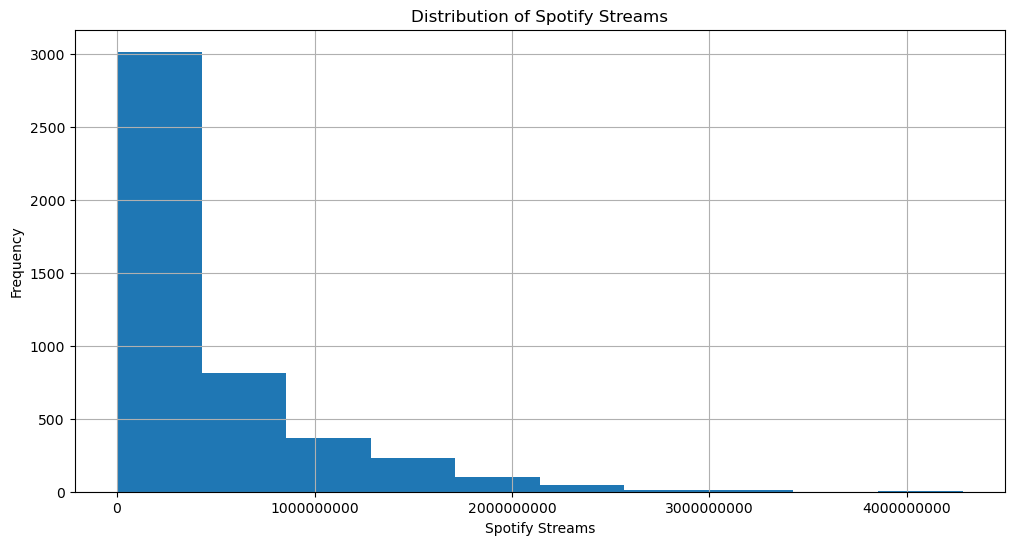

In [14]:
# TODO: Visualize the distribution of Spotify Streams

# Fill NaN in Spotify Streams with 0
df['Spotify Streams'].fillna(0, inplace=True)

# Convert to numeric
df['Spotify Streams'] = df['Spotify Streams'].replace({',':''}, regex=True)
df['Spotify Streams'] = pd.to_numeric(df['Spotify Streams'], errors ='coerce')

# Display the histogram
plt.figure(figsize=(12, 6))

plt.hist(df['Spotify Streams'])

plt.title('Distribution of Spotify Streams')
plt.xlabel('Spotify Streams')
plt.ylabel('Frequency')

formatter = FuncFormatter(lambda x, pos: '{:.0f}'.format(x))
plt.gca().xaxis.set_major_formatter(formatter)

plt.grid(True)

plt.show()

- What is your insights about above histogram?

    **TODO**:
  The Spotify Streams histogram has a left-skewed shpae meaning most songs has low streams but a few songs which may be 'hit' or 'viral' songs have extremly high streams.

#### 3.4.2. Boxplot:

Visualize the Boxplot of Track Score.

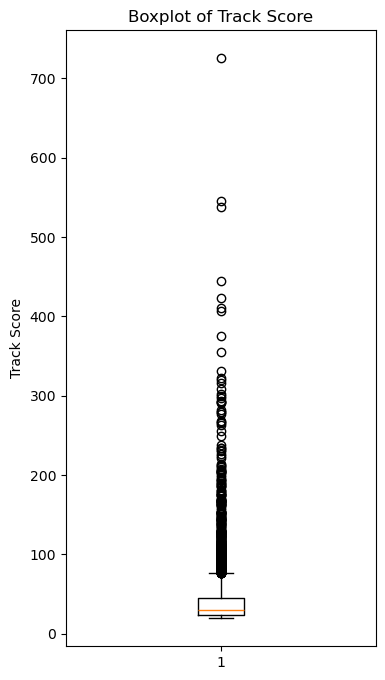

In [15]:
# TODO: Visualize the boxplot of Track Score
plt.figure(figsize=(4,8))
plt.boxplot(df['Track Score'])

plt.title('Boxplot of Track Score')
plt.ylabel('Track Score')
plt.show()

- What is your insights about above box plot?

    **TODO**: Most track scores are concentrated mainly in the lower part of chart. However, there are some and many songs having very high scores at the top, which could be hit songs.

#### 3.4.3. Pie chart:

Visualize the pie chart showing the distribution of Explicit Track.

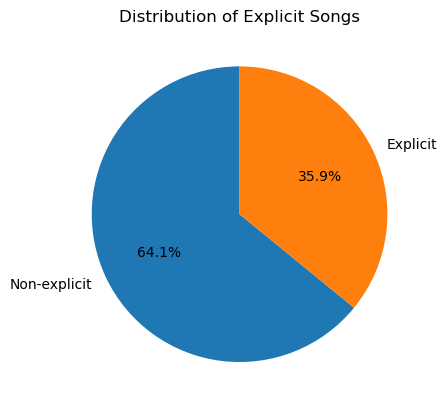

In [16]:
# TODO: Visualize the pie chart showing the distribution of Explicit Track
explicit_count = df['Explicit Track'].value_counts()

plt.figure()
plt.pie(explicit_count, autopct='%1.1f%%', labels=['Non-explicit', 'Explicit'], startangle=90)
plt.title('Distribution of Explicit Songs')

plt.show()

- What is your insights about above pie chart?

    **TODO**: Songs having explicit content account for more than 1/3 of the total number of the songs in 2024. This can be seen as a significant number, as it can reflect the current trend. Besides, songs with non-explicit content are still preferred by the majority of people.

## 4. Question proposing & Answering

- In this section, you are going to answer my 2 questions and prose 1 question. Note that these questions can all be answered by analyzing data. Theoretically, the proposed question have to benefit at a certain level. But this is exercise about `Pandas`, my questions can be aimed more at technical side than the meaningful side. But your question has to be meaningful :v

### 4.1. Top 10 songs by streams

Find and display the top 10 songs with the highest number of streams in 2024.

In [17]:
# TODO: Answer the question
top_10_songs_Spotify_streams = df.nlargest(10, 'Spotify Streams').reset_index(drop=True)
top_10_songs_Spotify_streams[['Track', 'Spotify Streams']]

,Track,Spotify Streams
0,Blinding Lights,4281468720
1,Blinding Lights,4261328190
2,Shape of You,3909458734
3,Shape of You,3888356417
4,Someone You Loved,3427498835
5,Sunflower - Spider-Man: Into the Spider-Verse,3358704125
6,As It Was,3301814535
7,As It Was,3299082422
8,Starboy,3291262413
9,One Dance,3192204066


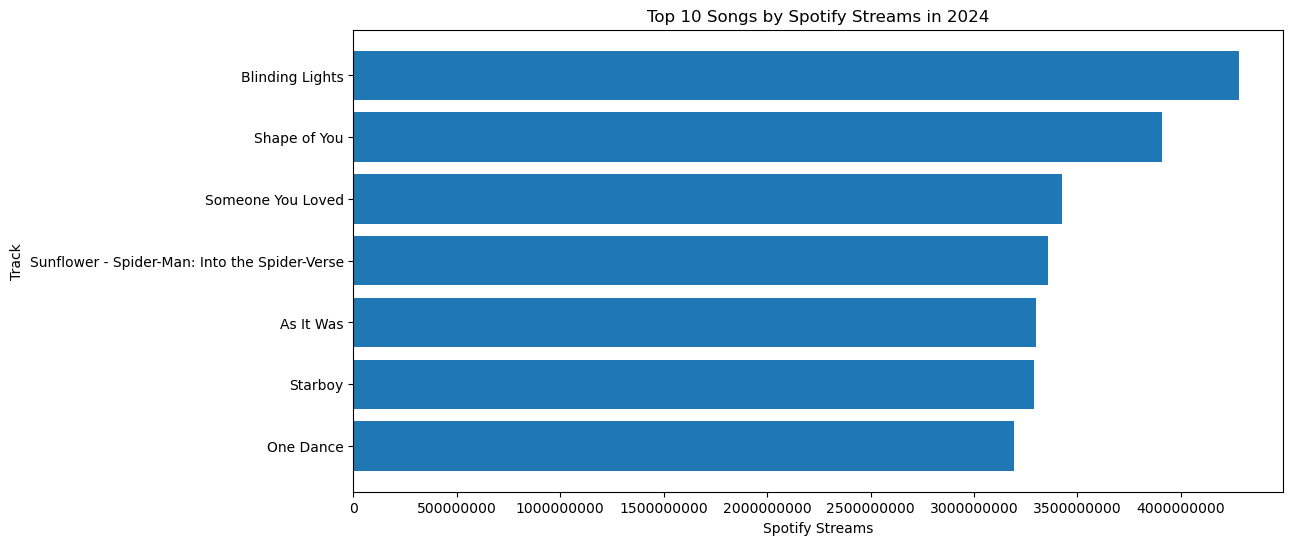

In [18]:
# TODO (OPTIONAL): Visualize
plt.figure(figsize=(12, 6))
plt.barh(top_10_songs_Spotify_streams['Track'], top_10_songs_Spotify_streams['Spotify Streams'])
plt.xlabel('Spotify Streams')
plt.ylabel('Track')
plt.title('Top 10 Songs by Spotify Streams in 2024')

plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(formatter)

plt.show()

### 4.2. Top 10 Artists by streams

Find and display the top 10 artists with the highest number of streams in 2024.

In [19]:
# TODO: Answer the question
artist_Spotify_streams = df.groupby('Artist')['Spotify Streams'].sum()
top_10_artists_Spotify_streams = artist_Spotify_streams.nlargest(10).reset_index()
top_10_artists_Spotify_streams

,Artist,Spotify Streams
0,Bad Bunny,37054834425
1,The Weeknd,36948540278
2,Drake,34962157577
3,Taylor Swift,34470771165
4,Post Malone,26137472958
5,Ed Sheeran,24014900390
6,Ariana Grande,23464991696
7,MUSIC LAB JPN,22866685573
8,Olivia Rodrigo,19729219749
9,Eminem,18878880174


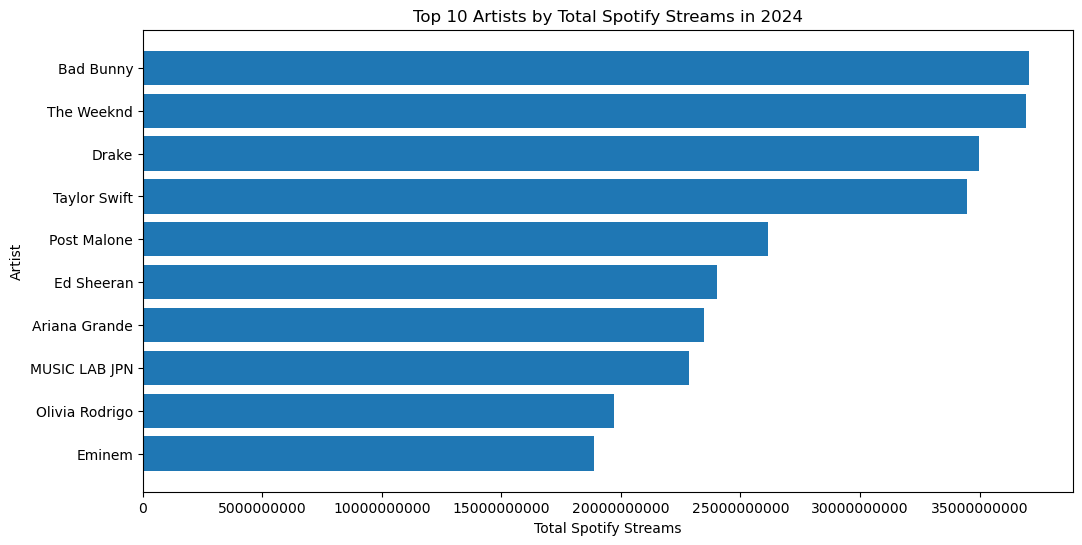

In [20]:
# TODO (OPTIONAL): Visualize
plt.figure(figsize=(12, 6))
plt.barh(top_10_artists_Spotify_streams['Artist'], top_10_artists_Spotify_streams['Spotify Streams'])
plt.xlabel('Total Spotify Streams')
plt.ylabel('Artist')
plt.title('Top 10 Artists by Total Spotify Streams in 2024')

plt.gca().invert_yaxis()
plt.gca().xaxis.set_major_formatter(formatter)

plt.show()

### 4.3. Your question?

How do Spotify Streams correlate with YouTube views and TikTok likes across the top 10 most streamed artists of 2024?

In [21]:
# TODO: Answer the question
top_10_artist_df = df[df['Artist'].isin(top_10_artists_Spotify_streams['Artist'])].reset_index(drop=True)

relevant_cols = ['Spotify Streams', 'YouTube Views', 'TikTok Likes']

# Fill missing values in the relevant columns with 0
top_10_artist_df[relevant_cols] = top_10_artist_df[relevant_cols].fillna(0)

# Convert to numeric
top_10_artist_df['YouTube Views'] = top_10_artist_df['YouTube Views'].replace({',':''}, regex=True)
top_10_artist_df['YouTube Views'] = pd.to_numeric(top_10_artist_df['YouTube Views'], errors='coerce')

top_10_artist_df['TikTok Likes'] = top_10_artist_df['TikTok Likes'].replace({',':''}, regex=True)
top_10_artist_df['TikTok Likes'] = pd.to_numeric(top_10_artist_df['TikTok Likes'], errors='coerce')

# Calculate correlation matrix among relevant columns
correlation_matrix = top_10_artist_df[relevant_cols].corr()

correlation_matrix

,Spotify Streams,YouTube Views,TikTok Likes
Spotify Streams,1.000000,0.557596,0.389534
YouTube Views,0.557596,1.000000,0.292198
TikTok Likes,0.389534,0.292198,1.000000


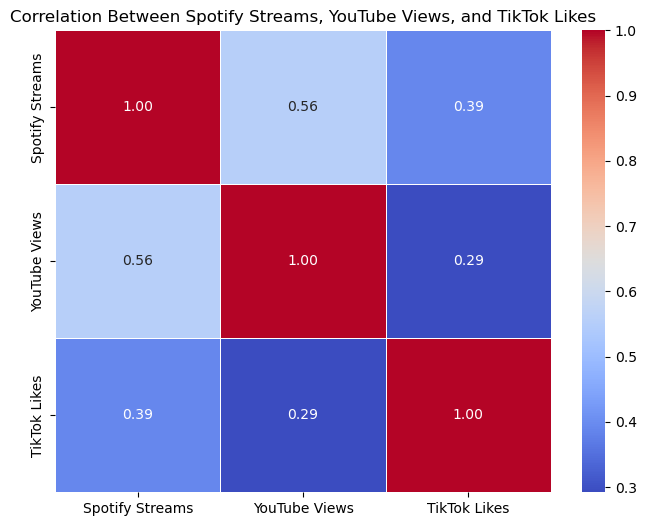

In [22]:
# TODO (OPTIONAL): Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Correlation Between Spotify Streams, YouTube Views, and TikTok Likes')
plt.show()

**TODO**

Your insights:
- **Spotify Streams** and **YouTube Views**:
    - The correlation coefficient between Spotify Streams and YouTube Views is **0.56**. In other words, when the number of Spotify streams increases, the YouTube views also tend to increase the in same trend for these artists.

- **Spotify Streams** and **TikTok Likes**:
    - The correlation between Spotify Streams and TikTok Likes is **0.39**, which is a weak to moderate positive correlation. This suggests that there is some relation between the number of the stream on Spotify and the TikTok favorites.

- **YouTube Views** and **TikTok Likes**:
    - The correlation between YouTube Views and TikTok Likes is **0.29**. This suggests that while there is some link between views on YouTube and likes on TikTok, the relationship is not very strong.


Well done!